In [260]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ppu.methods.beta import get_Beta
from ppu.methods.bregman import get_BI
from ppu.methods.tracin import get_random_tracin, get_random_resampled_tracin
from ppu.methods.mlp import MLP


In [2]:
train_data = pd.read_csv("/Users/hb70ur/PointPredictionUncertainty/notebooks/titanic/train.csv")
test_data = pd.read_csv("/Users/hb70ur/PointPredictionUncertainty/notebooks/titanic/test.csv")

In [3]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
full = pd.concat([train_data, test_data],axis=0)
full.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [422]:
mask = (full["Pclass"] == 1) & (full["Sex"] == "male")
OOD = full[mask]

In [438]:
y_OOD = OOD["Survived"]
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X_OOD = pd.get_dummies(OOD[features], dtype="float")

y_OOD = y_OOD.fillna(0)
X_OOD["Age"] = X_OOD["Age"].fillna(X_OOD["Age"].mean())



In [439]:
X_OOD

,Pclass,Age,SibSp,Parch,Fare,Sex_male
6,1,54.0,0,0,51.8625,1.0
23,1,28.0,0,0,35.5000,1.0
27,1,19.0,3,2,263.0000,1.0
30,1,40.0,0,0,27.7208,1.0
34,1,28.0,1,0,82.1708,1.0
...,...,...,...,...,...,...
378,1,55.0,0,0,50.0000,1.0
390,1,23.0,0,0,93.5000,1.0
403,1,17.0,0,0,47.1000,1.0
404,1,43.0,1,0,27.7208,1.0


In [440]:
X_OOD.shape

(179, 6)

In [442]:
X_OOD = np.hstack((X_OOD.to_numpy()[:,:-1], np.zeros((X_OOD.shape[0], 1))))
y_OOD = y_OOD.to_numpy()

In [443]:
#ID = pd.concat([full[full["Pclass"] == 2], full[full["Pclass"] == 3]],axis=0)
ID = full[~mask]

In [444]:
y = ID["Survived"]
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = pd.get_dummies(ID[features], dtype="float")

In [445]:
y = y.fillna(0)
X["Age"] = X["Age"].fillna(X["Age"].mean())


In [446]:
X

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male
0,3,22.000000,1,0,7.2500,0.0,1.0
1,1,38.000000,1,0,71.2833,1.0,0.0
2,3,26.000000,0,0,7.9250,1.0,0.0
3,1,35.000000,1,0,53.1000,1.0,0.0
4,3,35.000000,0,0,8.0500,0.0,1.0
...,...,...,...,...,...,...,...
413,3,28.000279,0,0,8.0500,0.0,1.0
414,1,39.000000,0,0,108.9000,1.0,0.0
415,3,38.500000,0,0,7.2500,0.0,1.0
416,3,28.000279,0,0,8.0500,0.0,1.0


In [447]:
X = X.to_numpy()[:,:-1]
y = y.to_numpy()

In [448]:
X

array([[ 3.        , 22.        ,  1.        ,  0.        ,  7.25      ,
         0.        ],
       [ 1.        , 38.        ,  1.        ,  0.        , 71.2833    ,
         1.        ],
       [ 3.        , 26.        ,  0.        ,  0.        ,  7.925     ,
         1.        ],
       ...,
       [ 3.        , 38.5       ,  0.        ,  0.        ,  7.25      ,
         0.        ],
       [ 3.        , 28.00027933,  0.        ,  0.        ,  8.05      ,
         0.        ],
       [ 3.        , 28.00027933,  1.        ,  1.        , 22.3583    ,
         0.        ]])

In [470]:
classifier = MLP(in_channels=6, hidden_channels=[30, 100, 200, 100, 50, 1], patience=3, frequency=3, lr=1e-2, device="mps")
#classifier.fit(X,y)

In [451]:
import random
from copy import deepcopy


def bootstrap(clf, X, y, n_models,):
    result = []
    seeds = range(n_models)
    n_samples = len(X)
    idx = np.arange(n_samples)
    for _ in seeds:
        bs_ind = random.choices(idx, k=n_samples)
        bs_X = X[bs_ind]
        bs_y = y[bs_ind]
        model = deepcopy(clf)
        model.fit(bs_X, bs_y)
        result.append(model)
    return result

In [471]:
models = bootstrap(classifier, X, y, 64)

In [472]:
ID_BI = get_BI(X, models)
OOD_BI = get_BI(X_OOD, models)

In [473]:
ID_BI.mean()

0.033278730673457345

In [474]:
OOD_BI.mean()



0.050544035435569366

(array([56., 34., 27., 27., 13.,  7.,  6.,  4.,  2.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  2.]),
 array([0.01835093, 0.03057695, 0.04280298, 0.055029  , 0.06725502,
        0.07948104, 0.09170707, 0.10393309, 0.11615911, 0.12838514,
        0.14061116, 0.15283718, 0.16506321, 0.17728923, 0.18951525,
        0.20174127, 0.2139673 , 0.22619332, 0.23841934, 0.25064537,
        0.26287139]),
 <BarContainer object of 20 artists>)

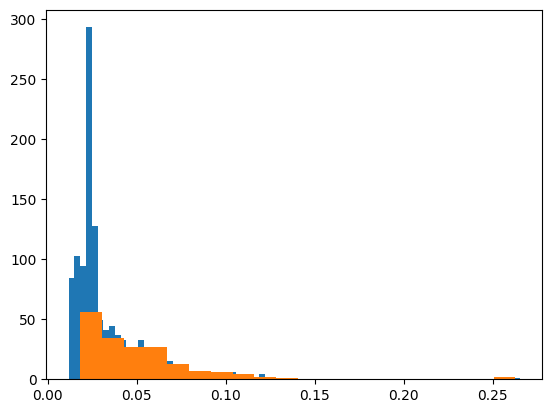

In [475]:
plt.hist(ID_BI, bins="auto")
plt.hist(OOD_BI, bins="auto")

In [476]:
ID_Beta = get_Beta(X, models)
OOD_Beta = get_Beta(X_OOD, models)

In [477]:
ID_Beta.mean()

0.06257317903335602

In [478]:
OOD_Beta.mean()

0.14976364417705199

(array([90.,  9., 14.,  8.,  7., 14.,  1., 15., 21.]),
 array([0.00769231, 0.05726496, 0.10683761, 0.15641026, 0.20598291,
        0.25555556, 0.30512821, 0.35470085, 0.4042735 , 0.45384615]),
 <BarContainer object of 9 artists>)

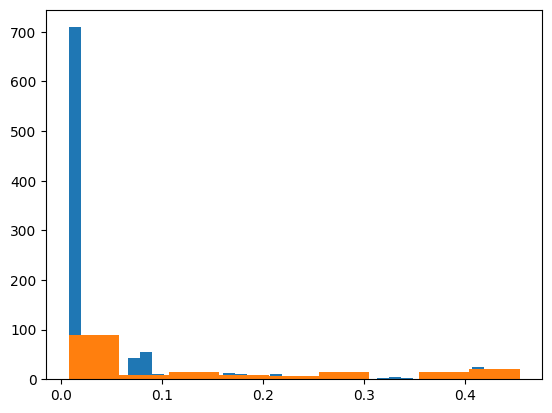

In [479]:
plt.hist(ID_Beta, bins="auto")
plt.hist(OOD_Beta, bins="auto")

In [480]:
tracin_ID_1 = get_random_tracin(X_test=X[np.random.choice(len(X), 200, replace=False)], y_test=1, X_train=X, y_train=y, mlp=models[0], n_iter=20, batch_size=200)
tracin_ID_0 = get_random_tracin(X_test=X[np.random.choice(len(X), 200, replace=False)], y_test=0, X_train=X, y_train=y, mlp=models[0], n_iter=20, batch_size=200)
tracin_ID = tracin_ID_0 + tracin_ID_1

In [481]:
tracin_ID

array([[1.00617933, 0.94068623, 0.73711431, ..., 0.57946818, 0.57667984,
        0.53540815],
       [0.23398668, 0.2090652 , 0.1669268 , ..., 0.53050008, 0.32588133,
        0.39145115],
       [1.02111393, 0.89967114, 0.69959426, ..., 0.3130889 , 0.32147139,
        0.30951865],
       ...,
       [1.21844965, 1.12803051, 0.90829593, ..., 0.3950405 , 0.40650076,
        0.37048198],
       [0.96969557, 0.94918263, 0.83216369, ..., 0.92010461, 0.86871006,
        0.80250746],
       [0.97842759, 0.86580959, 0.66648382, ..., 0.47104298, 0.4351187 ,
        0.3704361 ]])

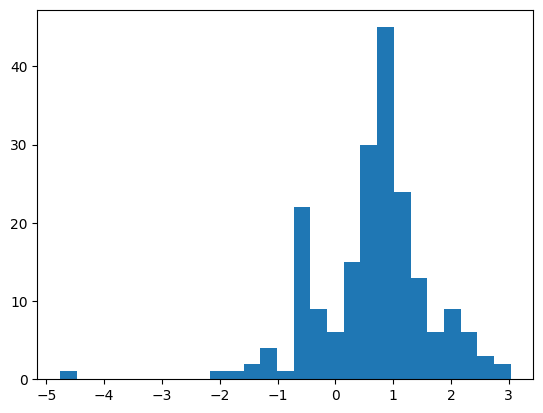

In [486]:
plt.hist(tracin_ID.T[0], bins="auto")
plt.show()

In [483]:
tracin_OOD_1 = get_random_tracin(X_test=X_OOD, y_test=1, X_train=X, y_train=y, mlp=models[0], n_iter=20, batch_size=200)
tracin_OOD_0 = get_random_tracin(X_test=X_OOD, y_test=0, X_train=X, y_train=y, mlp=models[0], n_iter=20, batch_size=200)
tracin_OOD = tracin_OOD_0 + tracin_OOD_1

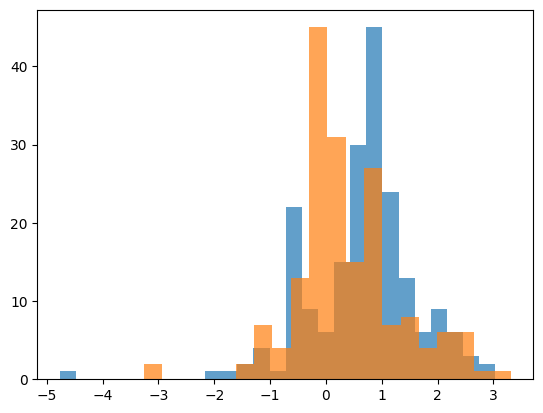

In [487]:
plt.hist(tracin_ID.T[0], bins="auto", alpha=0.7)
plt.hist(tracin_OOD.T[0], bins="auto", alpha=0.7)
plt.show()

In [227]:

from sklearn.inspection._plot.decision_boundary import _check_boundary_response_method

_check_boundary_response_method(models[62], "predict_proba")(X)

array([0.44190955, 0.43872645, 0.3939617 , ..., 0.41855747, 0.43316448,
       0.43469077], dtype=float32)

In [213]:
models[2].model(torch.from_numpy(X[0]).to(dtype=torch.float32))

tensor([nan], grad_fn=<ViewBackward0>)

In [238]:
preds = np.array([_check_boundary_response_method(m, "predict_proba")(X_OOD) for m in models])

In [239]:
preds.shape

(64, 277)

In [240]:
from ppu.methods.utils import LSE, LSE_LB_estimator_, stable_logit_transform
logits = stable_logit_transform(preds)

In [241]:
logits.shape

(64, 277)

In [255]:
logits.T[5]

array([-1.0036604 , -4.608194  , -2.6083894 , -0.7004416 , -5.517229  ,
       -1.0701258 , -0.86810374, -1.0943935 , -1.0949719 , -1.3014778 ,
       -0.6427033 , -0.6004249 , -1.0681231 , -1.073679  , -0.8009491 ,
       -1.0522633 , -0.832     , -4.9961505 , -1.0515301 , -0.9982729 ,
       -0.7594031 , -1.040648  , -0.81147397, -5.1654315 , -5.0584555 ,
       -2.9242263 , -1.0376065 , -1.0840757 , -1.0711871 , -4.8759103 ,
       -1.1140587 , -0.9953344 , -0.8617044 , -1.0770384 , -1.0536811 ,
       -4.0530667 , -1.0636212 , -0.77665657, -1.0555537 , -1.0659277 ,
       -5.232614  , -4.2297115 , -1.0575688 , -3.7764065 , -5.4067698 ,
       -3.9857028 , -2.435553  , -0.7955644 , -1.1147698 , -1.0855397 ,
       -1.0570018 , -0.6413331 , -0.8326261 , -1.0430157 , -2.9232242 ,
       -1.0058503 , -1.0832386 , -0.54981923, -1.0729384 , -1.0656778 ,
       -0.97402555, -1.0558708 , -1.0622301 , -0.4807402 ], dtype=float32)